<a href="https://colab.research.google.com/github/JJCG25/Chagas---Machine-Learning/blob/main/Exploracion_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LIBRERIAS**

In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/SISTEMAS🧠/HoCV/CHAGAS')
print(os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/SISTEMAS🧠/HoCV/CHAGAS


In [6]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns',None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# **CARGADO Y LIMPIEZA**

In [3]:
path= 'Base_tesis_chagas_IA_250725.xlsx'
df = pd.read_excel(path)
df.drop(columns=["Primera dosis","segunda dosis","Tercera dosis","Cuarta dosis", 'Vacunación COVID',
                 'Tipo vacuna',"Mortalidad tiempo","Fuma actualmente", "número de cigarrillos diarios",
                 "Años de fumador", 'IMCat','Tipo vacuna.1','Tipo vacuna.2','Tipo vacuna.3','cod',
                 'fechaingreso', 'anioingreso', 'Fecha aplicación','Fecha aplicación.1',
                 'Fecha aplicación.2','Fecha aplicación.3', 'Fecha mortalidad', 'Fecha trasplante',
                 'Fecha asistencia'], inplace=True)

df = df.drop(index=1036)
cols = ["IPA"]
df[cols] = df[cols].fillna(0)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036 entries, 0 to 1035
Data columns (total 73 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   tipodepaciente                                    1036 non-null   float64
 1   edad                                              1036 non-null   float64
 2   sexo                                              1036 non-null   float64
 3   estadocivil                                       1036 non-null   float64
 4   arearesidencia                                    1036 non-null   float64
 5   regimensalud                                      1036 non-null   float64
 6   educacion                                         1036 non-null   float64
 7   IPA                                               1036 non-null   float64
 8   Consumo alcohol                                   1036 non-null   float64
 9   AHA                

/tmp/ipython-input-3772705632.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Complicaciones cardiovasculares", data=df, palette="Set2")


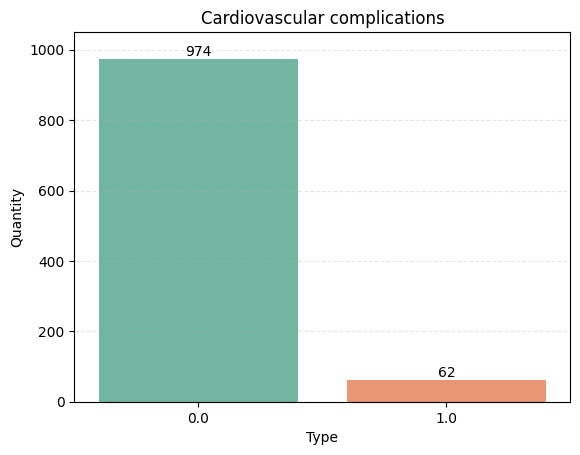

In [28]:
plt.figure()
ax = sns.countplot(x="Complicaciones cardiovasculares", data=df, palette="Set2")
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,  # posición horizontal (centro de la barra)
        height + 1,                     # posición vertical (un poco arriba)
        int(height),                    # valor mostrado
        ha="center", va="bottom"
    )

# Mejorar visualización
plt.title("Cardiovascular complications")
plt.xlabel("Type")
plt.ylabel("Quantity")
plt.ylim(0,1050)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

## **GRAFICAS**

/tmp/ipython-input-3593316243.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=countsdf, x="counts", y="variable", palette=colors)


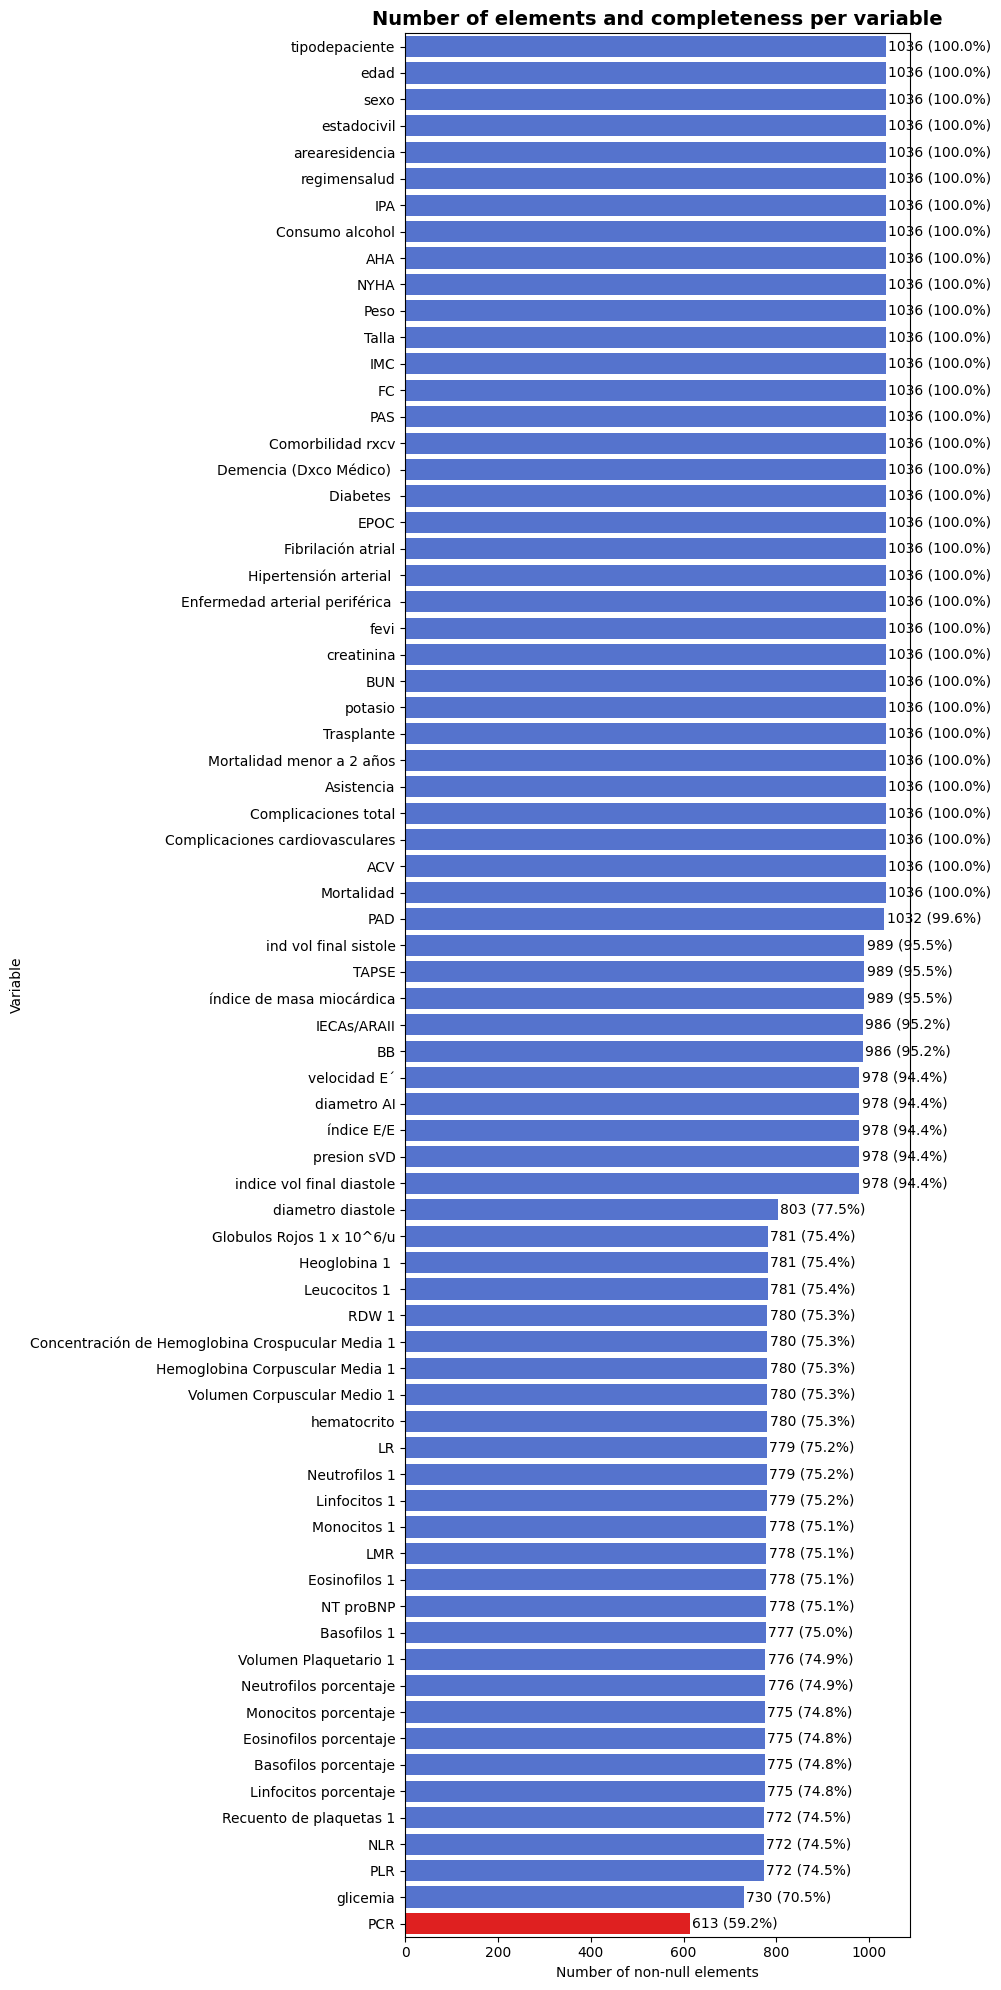

In [ ]:
#@title **Numero de elementos de cada columna**
counts = df.count().sort_values(ascending=False)
countsdf = pd.DataFrame({
    "counts": counts,
    "% completeness": counts / len(df) * 100
}).reset_index().rename(columns={"index": "variable"})

plt.figure(figsize=(10, 20))
colors = ["red" if v < 70 else "royalblue" for v in countsdf['% completeness']]

ax = sns.barplot(data=countsdf, x="counts", y="variable", palette=colors)
plt.title('Number of elements and completeness per variable', fontsize=14, weight='bold')

# === Añadir texto (número + porcentaje) al lado de cada barra ===
for i, (count, perc) in enumerate(zip(countsdf["counts"], countsdf["% completeness"])):
    ax.text(
        count + (len(df) * 0.005),  # un poquito a la derecha de la barra
        i,
        f"{int(count)} ({perc:.1f}%)",
        va='center', ha='left', fontsize=10, color='black'
    )

plt.xlabel("Number of non-null elements")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [ ]:
#@title **Correlaciones Metrices pequeñas**
#'pearson', 'spearman', 'kendall'
def plot_all_correlation_subplots(df, vars_per_plot=5, tipocorrelacion="pearson"):
    """
    Crea todos los subplots necesarios con las variables más correlacionadas
    organizadas de mayor a menor correlación
    """
    corr_matrix = df.corr(tipocorrelacion)

    # Encontrar todas las correlaciones fuertes
    corr_unstacked = corr_matrix.unstack()
    corr_unstacked = corr_unstacked[corr_unstacked.index.get_level_values(0) !=
                                   corr_unstacked.index.get_level_values(1)]

    # Ordenar por fuerza de correlación (de mayor a menor)
    strong_correlations = corr_unstacked.abs().sort_values(ascending=False)

    # Seleccionar TODAS las variables ordenadas por correlación
    used_variables = set()
    all_plots_data = []

    # Continuar hasta que todas las variables estén asignadas
    while len(used_variables) < len(df.columns):
        # Encontrar el mejor par disponible de variables no usadas
        available_pairs = [(pair, corr) for pair, corr in strong_correlations.items()
                          if pair[0] not in used_variables and pair[1] not in used_variables]

        if not available_pairs:
            # Si no hay más pares, añadir variables individuales restantes
            remaining_vars = [var for var in df.columns if var not in used_variables]
            if remaining_vars:
                # Agrupar variables restantes en grupos de vars_per_plot
                for i in range(0, len(remaining_vars), vars_per_plot):
                    group = remaining_vars[i:i + vars_per_plot]
                    if len(group) >= 2:  # Solo grupos con al menos 2 variables
                        all_plots_data.append(group)
                        used_variables.update(group)
            break

        # Tomar el mejor par disponible
        best_pair, best_corr = available_pairs[0]
        plot_vars = list(best_pair)

        # Añadir variables adicionales relacionadas (más correlacionadas primero)
        for pair, corr in strong_correlations.items():
            if len(plot_vars) >= vars_per_plot:
                break
            if (pair[0] in plot_vars and pair[1] not in plot_vars and
                pair[1] not in used_variables):
                plot_vars.append(pair[1])
            elif (pair[1] in plot_vars and pair[0] not in plot_vars and
                  pair[0] not in used_variables):
                plot_vars.append(pair[0])

        # Si el grupo es muy pequeño, añadir variables individuales correlacionadas
        if len(plot_vars) < vars_per_plot:
            # Encontrar variables más correlacionadas con el grupo actual
            group_correlations = []
            for var in df.columns:
                if var not in used_variables and var not in plot_vars:
                    # Calcular correlación promedio con el grupo actual
                    avg_corr = np.mean([abs(corr_matrix.loc[var, group_var])
                                      for group_var in plot_vars])
                    group_correlations.append((var, avg_corr))

            # Ordenar por correlación promedio y añadir las mejores
            group_correlations.sort(key=lambda x: x[1], reverse=True)
            for var, avg_corr in group_correlations:
                if len(plot_vars) >= vars_per_plot:
                    break
                plot_vars.append(var)

        all_plots_data.append(plot_vars)
        used_variables.update(plot_vars)

    # Crear subplots en lotes de 4 para mejor visualización
    n_total_plots = len(all_plots_data)
    print(f"Total de grupos creados: {n_total_plots}")

    # Procesar en lotes de 4 subplots
    for batch_start in range(0, n_total_plots, 4):
        batch_end = min(batch_start + 4, n_total_plots)
        batch_plots = all_plots_data[batch_start:batch_end]

        # Determinar layout del subplot
        n_batch_plots = len(batch_plots)
        n_rows = (n_batch_plots + 1) // 2  # Redondeo hacia arriba
        n_cols = 2 if n_batch_plots > 1 else 1

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 7 * n_rows))

        # Aplanar axes para fácil iteración
        if n_batch_plots > 1:
            axes = axes.ravel()
        else:
            axes = [axes]

        for i, plot_vars in enumerate(batch_plots):
            if i >= len(axes):
                break

            if len(plot_vars) < 2:
                continue

            plot_corr = df[plot_vars].corr()

            sns.heatmap(plot_corr,
                       annot=True,
                       cmap='coolwarm',
                       center=0,
                       fmt='.2f',
                       square=True,
                       cbar_kws={"shrink": 0.8},
                       ax=axes[i])

            axes[i].set_title(f'Grupo {batch_start + i + 1}')

        # Ocultar ejes vacíos
        for i in range(len(batch_plots), len(axes)):
            axes[i].set_visible(False)

        plt.tight_layout()
        plt.show()


#'pearson', 'spearman', 'kendall'

plot_all_correlation_subplots(df, vars_per_plot=5, tipocorrelacion='spearman')

In [ ]:
#@title **Histograma especifico**
sns.histplot(data=df,x='NLR',hue='tipodepaciente', alpha=0.4)
plt.grid(True)
plt.show()

In [8]:
#@title **Histogramas**
# Ruta segura donde guardar las imágenes
output_dir = "/content/drive/MyDrive/SISTEMAS🧠/HoCV/CHAGAS/Histogramas/Compl_Cardio"
os.makedirs(output_dir, exist_ok=True)

# Seleccionar solo las columnas numéricas (excepto tipodepaciente)
#numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop("tipodepaciente", errors="ignore")

# Generar histogramas comparando tipodepaciente con cada variable
for col in df:
    plt.figure(figsize=(10, 6))

    # Histograma para pacientes tipo 1
    plt.hist(
        df[df["Complicaciones cardiovasculares"] == 1][col],alpha=0.5, label="Compl. Cardio = 1")

    # Histograma para pacientes tipo 0
    plt.hist(
        df[df["Complicaciones cardiovasculares"] == 0][col], alpha=0.5, label="Compl. Cardio = 0")

    plt.title(f"{col} X complicaciones cardiovasculares")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)

    # Crear nombre de archivo seguro
    safe_col = re.sub(r'[\\/*?:"<>| ]', "_", col)
    filename = f"{safe_col}_hist_Compl_cardio.png"
    filepath = os.path.join(output_dir, filename)

    # Guardar imagen
    plt.savefig(filepath, bbox_inches="tight", dpi=200)
    plt.close()

print(f"histogramas guardados en: {output_dir}")

histogramas guardados en: /content/drive/MyDrive/SISTEMAS🧠/HoCV/CHAGAS/Histogramas/Compl_Cardio


In [ ]:
#@title **Correlaciones**
corr = df.corr()
plt.figure(figsize=(60,48))
print(corr.shape)
sns.heatmap(np.abs(corr)-np.eye(72), cmap='viridis')
plt.title("Matriz de correlación")
plt.show()

output_dir = "/content/drive/MyDrive/SISTEMAS🧠/HoCV/CHAGAS/Correlaciones"
os.makedirs(output_dir, exist_ok=True)

for col in corr.columns:
    correlaciones = corr[col].sort_values(ascending=False)

    plt.figure(figsize=(20, 12))
    sns.barplot(
        x=correlaciones.values,
        y=correlaciones.index,
        hue=correlaciones.index,
        palette="viridis",
        dodge=False
    )
    plt.title(f"{col}")
    plt.xlabel("Coeficiente de correlación (Pearson)")
    plt.ylabel("Variables")
    plt.legend([], [], frameon=False)

    # 🔒 Limpieza del nombre del archivo
    safe_col = re.sub(r'[\\/*?:"<>| ]', "_", col)
    filename = f"{safe_col}_correlaciones.png"
    filepath = os.path.join(output_dir, filename)

    plt.savefig(filepath, bbox_inches="tight", dpi=150)
    plt.close()

print(f"✅ Imágenes guardadas correctamente en: {output_dir}")

✅ Imágenes guardadas correctamente en: /content/drive/MyDrive/SISTEMAS🧠/HoCV/CHAGAS/Correlaciones


In [ ]:
#@title **Correlación para variables especificas entre si**
#'pearson', 'spearman', 'kendall'
def plot_subset_correlation(df, columns, figsize=(8,6), corre='pearson',):
    """
    Calcula y grafica la matriz de correlación solo para las columnas seleccionadas.
    """
    df_subset = df[columns]
    corr = df_subset.corr(corre)
    plt.figure(figsize=figsize)
    sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.title("Matriz de correlación (subset)")
    plt.show()

plot_subset_correlation(df, ["Eosinofilos porcentaje", "Eosinofilos 1", "hematocrito", "Globulos Rojos 1 x 10^6/u", "Peso", "edad"], figsize=(10,8),corre='pearson')

In [ ]:
#@title **PCA**
# --- Tu código base ---
df_fill_mean = df.fillna(df.mean(numeric_only=True))
X = df_fill_mean.drop(columns=['tipodepaciente'])
y = df_fill_mean['tipodepaciente']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# --- Encontrar el número mínimo de componentes que explican al menos el 90% ---
threshold = 0.90
n_components_90 = np.argmax(cumulative_variance >= threshold) + 1
variance_at_90 = cumulative_variance[n_components_90 - 1]

# --- Gráfico ---
plt.figure(figsize=(8,5))
plt.plot(cumulative_variance)
plt.axhline(y=variance_at_90, color='r', linestyle='--', label=f"{variance_at_90:.2%} varianza")
plt.axvline(x=n_components_90-1, color='r', linestyle='--', label=f"{n_components_90} componentes")
plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Explicada Acumulada")
plt.title("Curva de Varianza Explicada (PCA)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Se alcanzan {variance_at_90:.2%} de varianza explicada con {n_components_90} componentes.")

In [ ]:
#@title **PCA plot vectores**
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Hacemos un DataFrame para ploteo
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["group"] = y

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

plt.figure(figsize=(10, 8))
# Calcular la magnitud de cada vector de carga
loading_magnitudes = np.sqrt(loadings[:,0]**2 + loadings[:,1]**2)

# Seleccionar las k variables más importantes
k = 5
top_idx = np.argsort(loading_magnitudes)[-k:]

# Plot con solo las k más influyentes
plt.figure(figsize=(10, 8))

# Puntos (observaciones)
for group in np.unique(y):
    idx = y == group
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=str(group), alpha=0.3)

# Flechas solo de las más influyentes
for i in top_idx:
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1],
              color='r', alpha=0.7, head_width=0.05)
    plt.text(loadings[i, 0]*1.15, loadings[i, 1]*1.15,
             X.columns[i], color='r', ha='center', va='center')

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA Biplot (solo top variables)")
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True)
plt.show()

# **LDA**

In [ ]:
df_fill_mean = df.fillna(df.mean())
print(df.columns.tolist())

['tipodepaciente', 'edad', 'sexo', 'estadocivil', 'arearesidencia', 'regimensalud', 'educacion', 'IPA', 'Consumo alcohol', 'AHA', 'NYHA', 'Peso', 'Talla', 'IMC', 'FC', 'PAS', 'PAD', 'Comorbilidad rxcv', 'Diabetes\xa0', 'EPOC', 'Fibrilación atrial', 'Demencia (Dxco Médico)\xa0', 'Enfermedad arterial periférica\xa0', 'Hipertensión arterial\xa0', 'fevi', 'IECAs/ARAII', 'BB', 'NT proBNP', 'creatinina', 'potasio', 'glicemia', 'PCR', 'BUN', 'Globulos Rojos 1 x 10^6/u', 'Leucocitos 1 ', 'Heoglobina 1 ', 'hematocrito', 'Volumen Corpuscular Medio 1', 'Hemoglobina Corpuscular Media 1', 'Concentración de Hemoglobina Crospucular Media 1', 'Recuento de plaquetas 1', 'RDW 1', 'Volumen Plaquetario 1', 'Neutrofilos 1', 'Linfocitos 1', 'Monocitos 1', 'Eosinofilos 1', 'Basofilos 1', 'Neutrofilos porcentaje', 'Linfocitos porcentaje', 'Monocitos porcentaje', 'Eosinofilos porcentaje', 'Basofilos porcentaje', 'LR', 'PLR', 'LMR', 'NLR', 'Mortalidad', 'Mortalidad menor a 2 años', 'Trasplante', 'ACV', 'Asisten

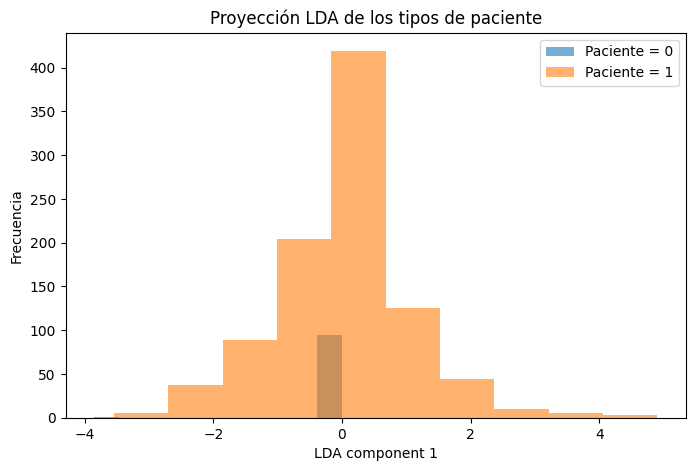

Varianza explicada por la(s) componente(s): [1.]


In [ ]:
'''
'tipodepaciente', 'AHA', 'NYHA',
                               'BB','fevi','IECAs/ARAII',
                               'Complicaciones total','Mortalidad',
                               'Mortalidad menor a 2 años','NT proBNP',
                               'Comorbilidad rxcv'
'''
X = df_fill_mean[[
    'Globulos Rojos 1 x 10^6/u',
    'Leucocitos 1 ',
    'Heoglobina 1 ',
    'hematocrito',
    'Volumen Corpuscular Medio 1',
    'Hemoglobina Corpuscular Media 1',
    'Concentración de Hemoglobina Crospucular Media 1',
    'Recuento de plaquetas 1',
    'RDW 1',
    'Volumen Plaquetario 1',
    'Neutrofilos 1',
    'Linfocitos 1',
    'Monocitos 1',
    'Eosinofilos 1',
    'Basofilos 1',
    'Neutrofilos porcentaje',
    'Linfocitos porcentaje',
    'Monocitos porcentaje',
    'Eosinofilos porcentaje',
    'Basofilos porcentaje'
]
]
y = df_fill_mean['tipodepaciente']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


lda = LDA(n_components=1)  # 1 porque solo hay 2 clases
X_lda = lda.fit_transform(X_scaled, y)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(X_lda[y == 0], label='Paciente = 0', alpha=0.6)
plt.hist(X_lda[y == 1], label='Paciente = 1', alpha=0.6)
plt.xlabel('LDA component 1')
plt.ylabel('Frecuencia')
plt.title('Proyección LDA de los tipos de paciente')
plt.legend()
plt.show()

explained_ratio = lda.explained_variance_ratio_
print("Varianza explicada por la(s) componente(s):", explained_ratio)